<a href="https://colab.research.google.com/github/sarbanibhadra/Regression-Model-linear-vs-mlp/blob/main/2025ag05587_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing Linear Models and MLPs 
## Using Energy consumption prediction dataset
### Deep Neural Networks (DNN) 


---



Tasks: Select a real-world dataset (≥ 500 samples, ≥ 10 <50 features), implement a baseline linear model from scratch (no sklearn models), implement an MLP from scratch,
compare performance on test data, analyze results.

Learning Objectives: Understand regression/classification fundamentals, implement gradient
descent, build neural networks without high-level libraries, evaluate and compare models,
analyze computational trade-offs.


---



In [ ]:
#********************************************************************
# Prepare setup and import libraries
#********************************************************************
import kagglehub
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

###Task 1: Dataset Selection


---


Load dataset, describe it, state regression/classification,
justify primary evaluation metric important for your dataset.

In [ ]:
#********************************************************************
# Download Energy Consumption Dataset from Kaggle
#********************************************************************
path = kagglehub.dataset_download("datasetengineer/southern-california-energy-consumption")
file_name = os.listdir(path)
print(path)
print(file_name)

Using Colab cache for faster access to the 'southern-california-energy-consumption' dataset.
/kaggle/input/southern-california-energy-consumption
['electricity_consumption_optimization_dataset.csv']


In [ ]:
#********************************************************************
# Load Energy Consumption Dataset from Kaggle
#********************************************************************
df = pd.read_csv(os.path.join(path, file_name[0]))
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52585 entries, 0 to 52584
Data columns (total 40 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Timestamp                            52585 non-null  object 
 1   Building Type                        52585 non-null  object 
 2   Energy Consumption (kWh)             52585 non-null  float64
 3   Temperature (°C)                     52585 non-null  float64
 4   Humidity (%)                         52585 non-null  float64
 5   Occupancy Rate (%)                   52585 non-null  float64
 6   Lighting Consumption (kWh)           52585 non-null  float64
 7   HVAC Consumption (kWh)               52585 non-null  float64
 8   Energy Price ($/kWh)                 52585 non-null  float64
 9   Carbon Emission Rate (g CO2/kWh)     52585 non-null  float64
 10  Power Factor                         52585 non-null  float64
 11  Voltage Levels (V)          

,Timestamp,Building Type,Energy Consumption (kWh),Temperature (°C),Humidity (%),Occupancy Rate (%),Lighting Consumption (kWh),HVAC Consumption (kWh),Energy Price ($/kWh),Carbon Emission Rate (g CO2/kWh),...,Energy Savings Target (%),Room-Level Energy Consumption (kWh),Zonal Heating/Cooling Data (kWh),Electric Vehicle Charging Status,Building Orientation,IoT Sensor Count,Thermal Comfort Index,Energy Savings Potential (%),Peak Demand Reduction Indicator,Carbon Emission Reduction Category
0,2018-01-01 00:00:00,Residential,74.679912,31.357437,62.472886,49.293544,9.892054,9.073339,0.053297,341.764320,...,16.208574,13.341547,6.719547,0,South,21.425365,80.807871,14.115263,0,Moderate Reduction
1,2018-01-01 01:00:00,Industrial,46.592761,30.229121,63.067770,65.039117,11.063696,26.487881,0.019031,427.270057,...,16.081108,11.750894,7.041203,1,South,34.385339,79.679998,4.107683,0,Moderate Reduction
2,2018-01-01 02:00:00,Commercial,58.836657,19.182581,65.030972,-16.599946,0.582297,10.385565,0.060282,278.064969,...,17.463861,24.297381,12.874189,0,North,67.588352,84.571954,4.130955,0,Moderate Reduction


### Dataset description
This dataset provides comprehensive energy consumption data collected from various buildings in Southern California, and is being used here for understanding relationships between buildings characteristics and consumption of energy. As energy consumption value is a continuous value, it is a
**regression** analysis.

###Dataset Features:
The dataset has 40 features and 52585 samples. The details of the dataset can be found here
https://www.kaggle.com/datasets/datasetengineer/southern-california-energy-consumption/data?select=electricity_consumption_optimization_dataset.csv
####Feature selection:
I want to predict Energy Consumption (kWh), so this is my **dependent variable (y)**.

Next, I find out the which features are independent and valid **predictors** of Energy Consumption and not derived or associated with Enerygy Consumption in the dataset. Based on that logic:

I have selected below features as **predictor variables**:
1. Building Type -
2. Building Age (years) -
3. Equipment Age (years) -
4. Building Size (m²) -
5. Window-to-Wall Ratio (%) -
6. Insulation Quality Score -
7. Building Orientation (encode) -
8. Temperature (°C) -
9. Humidity (%) -
10. Solar Irradiance (W/m²) -
11. Occupancy Rate (%) -
12. Occupancy Schedule (encode) -
13. Maintenance Status -
14. Demand Response Participation -
15. Electric Vehicle Charging Status -
16. IoT Sensor Count -
17. Power Factor -
18. Voltage Levels (V) -
19. Reactive Power (kVARh) -
20. Power Outage Indicator -
21. Indoor Temperature (°C) -
22. Thermal Comfort Index -
23. Energy Price ($/kWh) -
24. Local Energy Production (kWh) -
25. Smart Plug Usage (kWh) -
26. Water Usage (liters) -
27. Grid Stability Score -
28. Historical Energy Consumption (kWh)
29. Energy Efficiency Rating
                
I have removed:
1. Lighting Consumption (kWh)
2. HVAC Consumption (kWh) -
3. Room-Level Energy Consumption (kWh) -
4. Zonal Heating/Cooling Data (kWh) -
5. Energy Savings Target (%) -
6. Energy Savings Potential (%) -
7. Peak Demand Reduction Indicator -
8. Carbon Emission Rate (g CO2/kWh) -
9. Carbon Emission Reduction Category -

####Evaluation metric:
As it is regression problem, we use below metrics to assess model performance:
1. Mean Squared Error (MSE)
2. Root Mean Squared Error (RMSE)
3. Mean Absolute Error (MAE)
4. R² Score (Coefficient of Determination)


---



In [ ]:
#********************************************************************
# Reduce the dataset size by length and breadth for faster processing
# Reduce the length by selecting 2000 samples randomly
#********************************************************************
df_small = df.sample(n=4000, random_state=42)
df_small

,Timestamp,Building Type,Energy Consumption (kWh),Temperature (°C),Humidity (%),Occupancy Rate (%),Lighting Consumption (kWh),HVAC Consumption (kWh),Energy Price ($/kWh),Carbon Emission Rate (g CO2/kWh),...,Energy Savings Target (%),Room-Level Energy Consumption (kWh),Zonal Heating/Cooling Data (kWh),Electric Vehicle Charging Status,Building Orientation,IoT Sensor Count,Thermal Comfort Index,Energy Savings Potential (%),Peak Demand Reduction Indicator,Carbon Emission Reduction Category
29170,2021-04-30 10:00:00,Residential,45.732222,18.344313,78.405759,49.969860,23.069194,31.736860,0.108640,684.073062,...,13.181428,33.241305,4.489499,0,East,63.703618,73.565397,11.030690,0,No Reduction
25116,2020-11-12 12:00:00,Residential,51.069291,14.759990,60.466990,18.809202,7.527436,15.167048,0.145277,508.951172,...,21.641852,38.966855,13.328059,0,South,23.826531,59.863812,13.770540,0,No Reduction
12790,2019-06-17 22:00:00,Residential,50.347221,31.345478,52.043449,37.761382,21.792965,27.814602,0.104738,811.554010,...,20.761607,16.796325,10.601013,0,North,39.015128,107.554310,10.306721,0,Low Reduction
42991,2022-11-27 07:00:00,Residential,70.116033,12.689951,66.970034,62.422312,11.208491,20.335902,0.228686,286.057301,...,17.072544,41.479494,11.195011,0,East,26.655385,46.905415,9.801827,0,Low Reduction
5653,2018-08-24 13:00:00,Residential,32.195347,16.171530,47.064591,45.527946,17.730687,22.078807,0.166354,383.810411,...,13.301298,22.764014,4.056032,0,South,65.712288,63.195828,6.553973,0,Moderate Reduction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26599,2021-01-13 07:00:00,Residential,64.956905,21.675189,35.252910,67.051465,7.896404,19.055158,0.171417,687.022020,...,11.658798,9.216750,13.896705,0,South,39.781881,74.587765,11.433793,0,Moderate Reduction
16849,2019-12-04 01:00:00,Residential,80.942597,20.056495,77.015212,26.121103,11.898212,7.004132,0.172391,383.478409,...,17.965817,26.096563,8.956138,0,North,15.449782,86.665934,2.762194,1,High Reduction
28265,2021-03-23 17:00:00,Residential,62.426307,9.589552,83.599570,40.621195,8.307507,16.103884,0.182032,238.247019,...,10.685552,21.915804,17.301617,0,South,57.331732,55.487740,9.416878,0,Moderate Reduction
21385,2020-06-10 01:00:00,Residential,53.999263,4.823969,38.703431,49.135349,18.351856,21.867839,0.172505,242.049718,...,23.084235,32.664929,7.364033,0,South,31.429530,54.156197,10.226164,0,Low Reduction


In [ ]:
#********************************************************************
# Reduce the breadth by selecting features which are independent
#********************************************************************
selected_features = [
    'Building Type',
    'Humidity (%)',
    'Occupancy Rate (%)',
    'Temperature (°C)',
    # 'Reactive Power (kVARh)',
    'Indoor Temperature (°C)',
    'Building Age (years)',
    # 'Equipment Age (years)',
    'Building Size (m²)',
    'Window-to-Wall Ratio (%)',
    'Insulation Quality Score',
    'Occupancy Schedule',
    'Local Energy Production (kWh)',
    'Solar Irradiance (W/m²)',
    'Smart Plug Usage (kWh)',
    'Building Orientation',
    # 'IoT Sensor Count',
    'Thermal Comfort Index',
    'Energy Consumption (kWh)'
]

df_small = df_small[selected_features]
df_small.head()
df_small.shape
df_small.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 29170 to 45563
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Building Type                  4000 non-null   object 
 1   Humidity (%)                   4000 non-null   float64
 2   Occupancy Rate (%)             4000 non-null   float64
 3   Temperature (°C)               4000 non-null   float64
 4   Indoor Temperature (°C)        4000 non-null   float64
 5   Building Age (years)           4000 non-null   float64
 6   Building Size (m²)             4000 non-null   float64
 7   Window-to-Wall Ratio (%)       4000 non-null   float64
 8   Insulation Quality Score       4000 non-null   float64
 9   Occupancy Schedule             4000 non-null   object 
 10  Local Energy Production (kWh)  4000 non-null   float64
 11  Solar Irradiance (W/m²)        4000 non-null   float64
 12  Smart Plug Usage (kWh)         4000 non-null   f

###Task 2: Data Preprocessing


---


Train-test split (70-30/80–20/ 90–10), handle missing
values, encode categorical variables, scale features, etc.


In [ ]:
#********************************************************************
# Handle categorical data
#********************************************************************
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df_small[['Building Type', 'Occupancy Schedule', 'Building Orientation']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Building Type', 'Occupancy Schedule', 'Building Orientation']), index=df_small.index)
encoded_df

,Building Type_Commercial,Building Type_Industrial,Building Type_Residential,Occupancy Schedule_Occupied,Occupancy Schedule_Vacant,Building Orientation_East,Building Orientation_North,Building Orientation_South,Building Orientation_West
29170,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
25116,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
12790,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
42991,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
5653,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
26599,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
16849,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
28265,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
21385,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
#********************************************************************
# Concatenate onehotencoded columns with model dataset
#********************************************************************
df_encoded = pd.concat([df_small.drop(['Building Type', 'Occupancy Schedule', 'Building Orientation'], axis=1), encoded_df], axis=1 )
print(df_encoded.shape)
print(df_encoded.head())



(4000, 22)
       Humidity (%)  Occupancy Rate (%)  Temperature (°C)  \
29170     78.405759           49.969860         18.344313   
25116     60.466990           18.809202         14.759990   
12790     52.043449           37.761382         31.345478   
42991     66.970034           62.422312         12.689951   
5653      47.064591           45.527946         16.171530   

       Indoor Temperature (°C)  Building Age (years)  Building Size (m²)  \
29170                16.011926              7.233003         1287.985030   
25116                25.415600             18.549702         1016.219403   
12790                18.680919             34.659912         1036.111894   
42991                18.327811              5.108221         1400.905114   
5653                 20.033123             12.620047          568.188285   

       Window-to-Wall Ratio (%)  Insulation Quality Score  \
29170                 38.008645                  5.113894   
25116                 35.806132            

In [ ]:
#********************************************************************
# Count outliers in each feature
#********************************************************************
Q1 = df_encoded.quantile(0.25)
Q3 = df_encoded.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_encoded < (Q1 - 1.5 * IQR)) | (df_encoded > (Q3 + 1.5 * IQR)))

# Count outliers per column
outlier_counts = outliers.sum()
print(outlier_counts.sort_values(ascending=False))

Building Orientation_West        834
Building Type_Commercial         800
Building Orientation_East        770
Building Type_Industrial         367
Smart Plug Usage (kWh)            45
Thermal Comfort Index             40
Building Age (years)              38
Occupancy Rate (%)                33
Temperature (°C)                  31
Building Size (m²)                31
Local Energy Production (kWh)     30
Solar Irradiance (W/m²)           29
Insulation Quality Score          27
Humidity (%)                      25
Window-to-Wall Ratio (%)          23
Energy Consumption (kWh)          22
Indoor Temperature (°C)           21
Building Type_Residential          0
Occupancy Schedule_Vacant          0
Occupancy Schedule_Occupied        0
Building Orientation_North         0
Building Orientation_South         0
dtype: int64


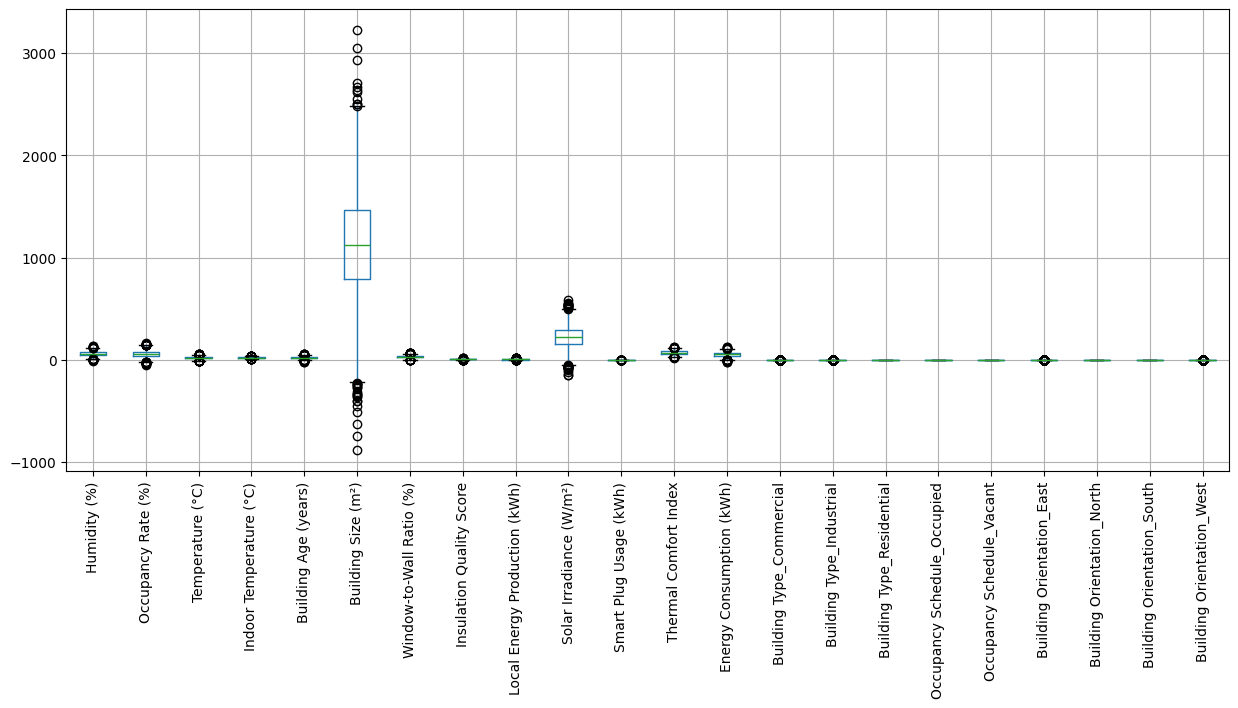

In [ ]:
#********************************************************************
# View outliers in each feature
#********************************************************************
df_encoded.boxplot(figsize=(15,6), rot=90)
plt.show()

In [ ]:
#********************************************************************
# Apply IQR to numeric columns ONLY — not to OHE binary columns
#********************************************************************
numeric_cols_iqr = [c for c in df_encoded.columns
                    if not any(c.startswith(p) for p in
                               ['Building Type_', 'Occupancy Schedule_', 'Building Orientation_'])]

Q1  = df_encoded[numeric_cols_iqr].quantile(0.25)
Q3  = df_encoded[numeric_cols_iqr].quantile(0.75)
IQR = Q3 - Q1

df_encoded = df_encoded[
    ~((df_encoded[numeric_cols_iqr] < (Q1 - 1.5 * IQR)) |
      (df_encoded[numeric_cols_iqr] > (Q3 + 1.5 * IQR))).any(axis=1)
]
print(df_encoded.shape)


(3630, 22)


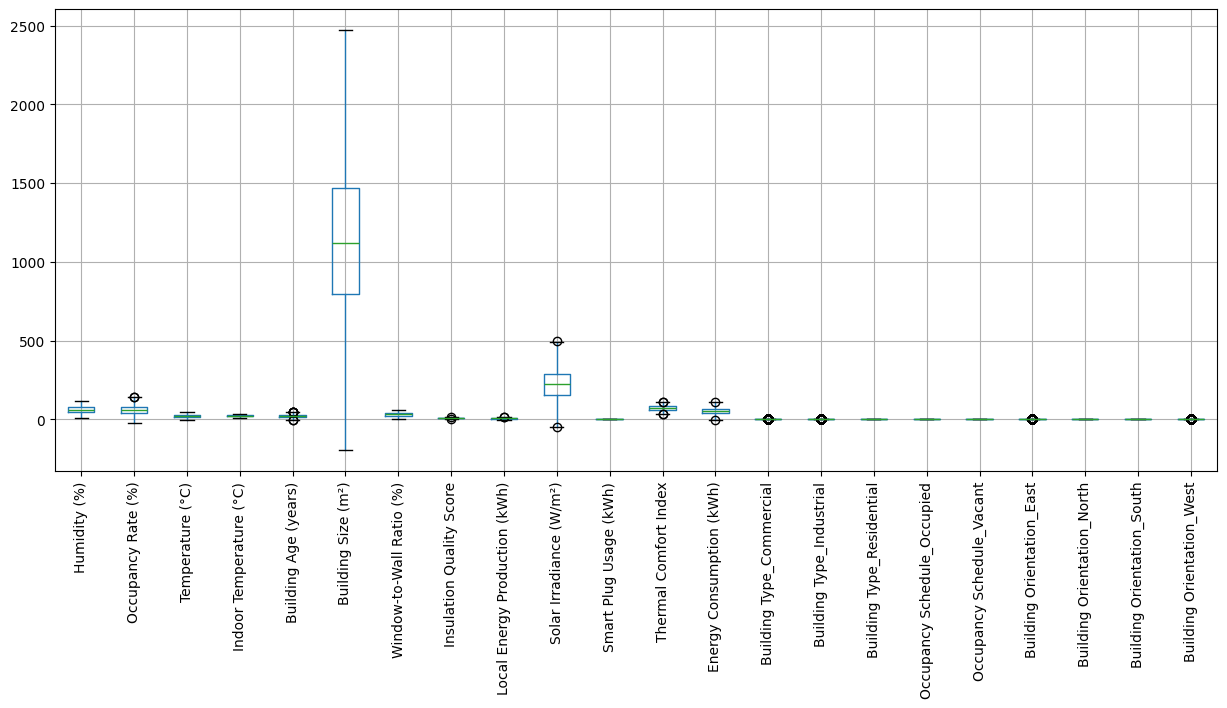

In [ ]:
#********************************************************************
# View outliers in each feature after IQR
#********************************************************************

df_encoded.boxplot(figsize=(15,6), rot=90)
plt.show()

In [ ]:
max(df_encoded["Building Size (m²)"])

2471.1063823451736

In [ ]:
#********************************************************************
# Define Target and features
#********************************************************************
X = df_encoded.drop(columns=["Energy Consumption (kWh)"]).values
y = df_encoded["Energy Consumption (kWh)"].values

In [ ]:
#********************************************************************
# Train-test split (70-30/80–20/ 90–10)
#********************************************************************
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")



Train set size: 2904 samples
Test set size: 726 samples


In [ ]:
#********************************************************************
# Scale features
#********************************************************************
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\nFeatures standardized (zero mean, unit variance)")
X_train_scaled, X_test_scaled

# Scale the target variable
from sklearn.preprocessing import StandardScaler
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
print("Rows after IQR:", df_encoded.shape)
print("y stats:", y_train.mean(), y_train.std(), y_train.min(), y_train.max())
print("X_train_scaled stats: mean=", X_train_scaled.mean().round(4), "std=", X_train_scaled.std().round(4))
print("y_train_scaled stats: mean=", y_train_scaled.mean().round(4), "std=", y_train_scaled.std().round(4))
print("W1 init scale:", np.sqrt(2./X_train_scaled.shape[1]).round(6))


Features standardized (zero mean, unit variance)
Rows after IQR: (3630, 22)
y stats: 53.52768843096477 20.162695486910522 -1.7912416018346922 109.5200487554089
X_train_scaled stats: mean= 0.0515 std= 0.6298
y_train_scaled stats: mean= 0.0 std= 1.0
W1 init scale: 0.308607


 ### Task 3- Baseline Model Development


---


Implement from scratch, initialize weights, forward pass,
compute loss, compute gradients, update weights (w = w – lr × grad), store loss at every iteration
(loss_history required), implement predict() function which will return prediction.

In [ ]:
# ============================================================================
# Linear Regression class of Single Neuron
# ============================================================================
class SingleNeuronLinearRegression:
    """
    Single neuron linear regression model from scratch
    """
    def __init__(self, learning_rate=0.001, epoch=500, random_seed=42):
        """
        Initialize the SingleNeuronLinearRegression model
        learning rate,
        epochs,
        random seed,
        weights,
        bias,
        loss history
        """
        self.learning_rate = learning_rate
        self.epoch = epoch
        self.random_seed = random_seed
        self.weights = None
        self.bias = None
        self.loss_history = []

    def initialize_parameters(self, n_features):
        """
        Initialize parameters
        """
        np.random.seed(self.random_seed)
        self.weights = np.random.randn(n_features) * np.sqrt(2. / n_features)
        self.bias = 0.0

    def predict(self, X):
        """
        Predict the output
        """
        return np.dot(X, self.weights) + self.bias

    def compute_loss(self, y, y_pred):
        """
        Compute Mean Squared Error loss loss
        """
        N = len(y)
        return (1 / (2 * N)) * np.sum((y - y_pred) ** 2)

    def compute_gradients(self, X, y, y_pred):
        """
        Compute the gradients
        """
        m = X.shape[0]
        dw = (1 / m) * np.dot(X.T, (y_pred - y))
        db =  (1 / m) * np.sum(y_pred - y)
        return dw, db

    def update_parameters(self, dw, db):
        """
        Update the parameters
        """
        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db


    def run(self, X, y, verbose=True):
        """
        Train the model
        """
        n_samples, n_features = X.shape

        # Step 1. Initilize the parameters
        self.initialize_parameters(n_features)

        start_time = time.time()
        for epoch in range(self.epoch):
          # Step 2. Predict the output
          y_pred = self.predict(X)

          # Step 3. Compute the loss
          loss = self.compute_loss(y, y_pred)
          self.loss_history.append(loss)

          # Step 4. Compute the gradients
          dw, db = self.compute_gradients(X, y, y_pred)

          # Step 5. Update the parameters
          self.update_parameters(dw, db)

          # Step 6. Print progress
          if verbose and (epoch % 500 == 0 or epoch == self.epoch - 1):
              print(f"Iteration {epoch:4d} | Loss: {loss:.4f} ")
        end_time = time.time()
        training_time = end_time - start_time
        self.time = training_time
        print(f"Training time: {training_time:.2f} seconds")

        if verbose:
            print(f"\nTraining completed!")
            print(f"Final Loss: {self.loss_history[-1]:.4f}")

    def model_architecture(self):
        return {
            "Input size": X.shape[1],
            "Learning rate": self.learning_rate,
            "Training time": str(round(self.time, 2)) + "s"
        }

In [ ]:
# ============================================================================
# Evaluation Metrics
# ============================================================================

def compute_metrics(y_true, y_pred):
    """
    Compute various regression metrics
    """
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }

In [ ]:
# ============================================================================
# Train model
# ============================================================================
linReg = SingleNeuronLinearRegression(learning_rate=0.01, epoch=5000)
linReg.run(X_train_scaled, y_train_scaled, verbose=True)

# Training completed!
# Final Loss: 203.8548

Iteration    0 | Loss: 0.7742 
Iteration  500 | Loss: 0.5089 
Iteration 1000 | Loss: 0.4992 
Iteration 1500 | Loss: 0.4980 
Iteration 2000 | Loss: 0.4978 
Iteration 2500 | Loss: 0.4977 
Iteration 3000 | Loss: 0.4977 
Iteration 3500 | Loss: 0.4977 
Iteration 4000 | Loss: 0.4977 
Iteration 4500 | Loss: 0.4977 
Iteration 4999 | Loss: 0.4977 
Training time: 0.34 seconds

Training completed!
Final Loss: 0.4977


In [ ]:
# y_train_pred = model.predict(X_train_scaled)
y_pred_train = y_scaler.inverse_transform(linReg.predict(X_train_scaled).reshape(-1,1)).flatten()
train_metrics = compute_metrics(y_train, y_pred_train)

print(f"\nTraining Set Metrics:")
print(f"  MSE:  {train_metrics['MSE']:.4f}")
print(f"  RMSE: {train_metrics['RMSE']:.4f}")
print(f"  MAE:  {train_metrics['MAE']:.4f}")
print(f"  R²:   {train_metrics['R²']:.4f}")


Training Set Metrics:
  MSE:  404.6371
  RMSE: 20.1156
  MAE:  16.2482
  R²:   0.0047


In [ ]:
y_pred_test_lin = y_scaler.inverse_transform(linReg.predict(X_test_scaled).reshape(-1,1)).flatten()
train_metrics = compute_metrics(y_test, y_pred_test_lin)

print(f"\nTesting Set Metrics:")
print(f"  MSE:  {train_metrics['MSE']:.4f}")
print(f"  RMSE: {train_metrics['RMSE']:.4f}")
print(f"  MAE:  {train_metrics['MAE']:.4f}")
print(f"  R²:   {train_metrics['R²']:.4f}")


Testing Set Metrics:
  MSE:  378.0369
  RMSE: 19.4432
  MAE:  15.5405
  R²:   -0.0080


### Task4 -Multi-Layer Perceptron Development


---


At least 1 hidden layer, ReLU for hidden layers, appropriate output activation, full forward propagation, backpropagation using chain rule,
gradient descent updates, loss_history required, architecture format: [input, hidden1, hidden2, …,
output].

In [ ]:
# ============================================================================
# MLP class with two hidden layers
# ============================================================================
class MLP:
    def __init__(self, input_size, hidden1=64, hidden2=32, lr=0.001, lamda=0.01, epochs=3000):
        self.lr = lr
        self.lamda = lamda
        self.epochs = epochs
        self.loss_history = []
        self.hidden1 = hidden1
        self.hidden2 = hidden2
        self.time = 0

    def initialize_parameters(self, input_size, hidden1, hidden2):
        self.W1 = np.random.randn(input_size, hidden1) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((1, hidden1))

        # self.W2 = np.random.randn(hidden1, hidden2) * c
        self.W2 = np.random.randn(hidden1, hidden2)    * np.sqrt(2. / hidden1)
        self.b2 = np.zeros((1, hidden2))

        # self.W3 = np.random.randn(hidden2, 1) * c
        self.W3 = np.random.randn(hidden2, 1)          * np.sqrt(2. / hidden2)
        self.b3 = np.zeros((1, 1))

    # activation
    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    # forward pass
    def forward_propagation(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        #self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.relu(self.Z1)

        #self.Z2 = self.A1 @ self.W2 + self.b2
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.relu(self.Z2)

        #self.Z3 = self.A2 @ self.W3 + self.b3  # output (linear)
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        return self.Z3

    # backward pass
    def backward_propagation(self, X, y, y_pred):
        m = X.shape[0]
        y = y.reshape(-1, 1)

        # output layer
        dZ3 = (y_pred - y) / m
        dW3 = np.dot(self.A2.T, dZ3)
        dW3 += 2 * self.lamda * self.W3
        db3 = np.sum(dZ3, axis=0)

        # hidden layer 2
        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * self.relu_derivative(self.Z2)
        dW2 = np.dot(self.A1.T, dZ2)
        dW2 += 2 * self.lamda * self.W2
        db2 = np.sum(dZ2, axis=0)

        # hidden layer 1
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1)
        dW1 += 2 * self.lamda * self.W1
        db1 = np.sum(dZ1, axis=0)

        # update
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3

    # training
    def run(self, X, y, verbose=True):
        N = X.shape[0]
        self.initialize_parameters( X.shape[1], self.hidden1, self.hidden2)
        start_time = time.time()
        for epoch in range(self.epochs):
            y_pred = self.forward_propagation(X)
            loss = (1 / (2 * N)) * np.sum((y.reshape(-1,1) - y_pred)**2) + (self.lamda * (np.sum(self.W1**2) + np.sum(self.W2**2) + np.sum(self.W3**2)))
            # loss = (1 / (2 * N)) * np.sum((y.reshape(-1,1) - y_pred)**2)
            self.loss_history.append(loss)
            self.backward_propagation(X, y, y_pred)
            if verbose and (epoch % 500 == 0 or epoch == self.epochs - 1):
              print(f"Iteration {epoch:4d} | Loss: {loss:.4f} ")
        end_time = time.time()
        training_time = end_time - start_time
        self.time = training_time
        print(f"Training time: {training_time:.2f} seconds")
        if verbose:
            print(f"\nTraining completed!")
            print(f"Final Loss: {self.loss_history[-1]:.4f}")

    # prediction
    def predict(self, X):
        return self.forward_propagation(X)

    def model_architecture(self):
        return {
            "Input size": self.W1.shape[0],
            "Hidden layers": 2,
            "Hidden 1": self.W1.shape[1],
            "Hidden 2": self.W2.shape[1],
            "Output size": self.W3.shape[1],
            "Learning rate": self.lr,
            "Regularization parameter value": self.lamda,
            "Training time": str(round(self.time, 2)) + "s"
        }

In [ ]:
# ============================================================================
# Train the MLP
# ============================================================================
mlp = MLP(input_size=X_train_scaled.shape[1], hidden1=32, hidden2=8, lr=0.01, lamda=0.0001, epochs=5000)

# mlp.run(X_train_scaled, y_train)
mlp.run(X_train_scaled, y_train_scaled)

# y_pred_mlp = mlp.predict(X_train_scaled).flatten()
y_pred_train = y_scaler.inverse_transform(mlp.predict(X_train_scaled).reshape(-1,1)).flatten()

train_metrics = compute_metrics(y_train, y_pred_train)

print(f"\nTraining Set Metrics:")
print(f"  MSE:  {train_metrics['MSE']:.4f}")
print(f"  RMSE: {train_metrics['RMSE']:.4f}")
print(f"  MAE:  {train_metrics['MAE']:.4f}")
print(f"  R²:   {train_metrics['R²']:.4f}")


# Training Set Metrics:
#   MSE:  407.7095
#   RMSE: 20.1918
#   MAE:  16.0074
#   R²:   0.0139

# Training Set Metrics:
#   MSE:  376.7089
#   RMSE: 19.4090
#   MAE:  15.5735
#   R²:   0.1085

# Training Set Metrics:
#   MSE:  207.2848
#   RMSE: 14.3974
#   MAE:  11.3753
#   R²:   0.5095

Iteration    0 | Loss: 0.8261 
Iteration  500 | Loss: 0.5152 
Iteration 1000 | Loss: 0.5090 
Iteration 1500 | Loss: 0.5074 
Iteration 2000 | Loss: 0.5067 
Iteration 2500 | Loss: 0.5061 
Iteration 3000 | Loss: 0.5056 
Iteration 3500 | Loss: 0.5051 
Iteration 4000 | Loss: 0.5047 
Iteration 4500 | Loss: 0.5042 
Iteration 4999 | Loss: 0.5037 
Training time: 17.38 seconds

Training completed!
Final Loss: 0.5037

Training Set Metrics:
  MSE:  403.5242
  RMSE: 20.0879
  MAE:  16.2332
  R²:   0.0074


In [ ]:
# y_pred_mlp = mlp.predict(X_test_scaled).flatten()
y_pred_test_mlp  = y_scaler.inverse_transform(mlp.predict(X_test_scaled).reshape(-1,1)).flatten()

# y_train_pred = model.predict(X_train_scaled)
train_metrics = compute_metrics(y_test, y_pred_test_mlp)

print(f"\nTesting Set Metrics:")
print(f"  MSE:  {train_metrics['MSE']:.4f}")
print(f"  RMSE: {train_metrics['RMSE']:.4f}")
print(f"  MAE:  {train_metrics['MAE']:.4f}")
print(f"  R²:   {train_metrics['R²']:.4f}")

# Training Set Metrics:
#   MSE:  472.2358
#   RMSE: 21.7310
#   MAE:  17.0587
#   R²:   -0.1307
# Testing Set Metrics:
#   MSE:  607.2017
#   RMSE: 24.6415
#   MAE:  19.4677
#   R²:   -0.5668


Testing Set Metrics:
  MSE:  373.7407
  RMSE: 19.3324
  MAE:  15.4486
  R²:   0.0035


### Task 5: Evaluation & Comparison

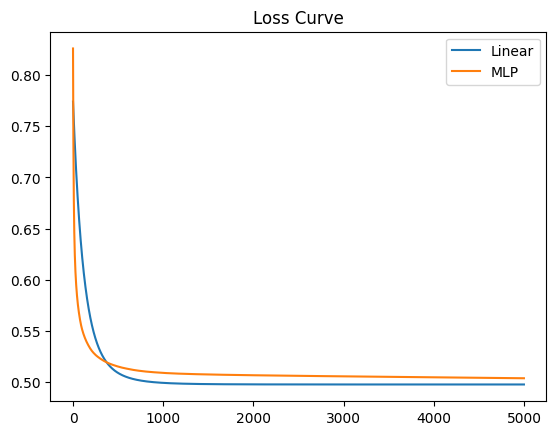

In [ ]:
# ============================================================================
# View loss curve
# ============================================================================
import matplotlib.pyplot as plt
plt.plot(linReg.loss_history, label="Linear")
plt.plot(mlp.loss_history, label="MLP")
plt.legend()
plt.title("Loss Curve")
plt.show()

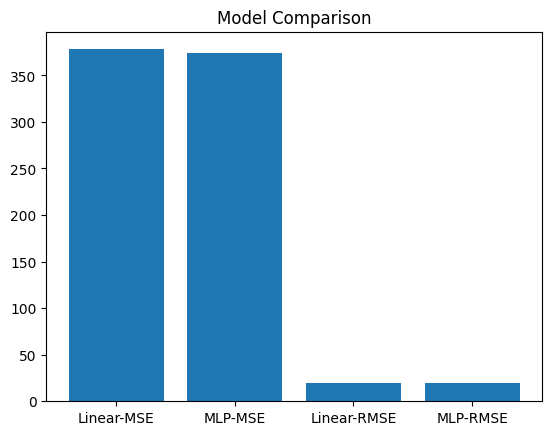

In [ ]:
# ============================================================================
# View model comparison graph
# ============================================================================
plt.bar(["Linear-MSE", "MLP-MSE", "Linear-RMSE", "MLP-RMSE"], [
    compute_metrics(y_test, y_pred_test_lin).get('MSE'),
    compute_metrics(y_test, y_pred_test_mlp).get('MSE'),
    compute_metrics(y_test, y_pred_test_lin).get('RMSE'),
    compute_metrics(y_test, y_pred_test_mlp).get('RMSE'),
])
plt.title("Model Comparison")
plt.show()

In [ ]:
# ============================================================================
# View assignment results
# ============================================================================
def get_assignment_results():
    baseline_metrics = compute_metrics(y_test, y_pred_test_lin)
    mlp_metrics = compute_metrics(y_test, y_pred_test_mlp)

    def format_metrics(m):
        return (
            f"    MSE  : {float(m['MSE']):>10.4f}\n"
            f"    RMSE : {float(m['RMSE']):>10.4f}\n"
            f"    MAE  : {float(m['MAE']):>10.4f}\n"
            f"    R²   : {float(m['R²']):>10.4f}"
        )

    def format_arch(arch):
        return "\n".join([f"    {k:<15}: {v}" for k, v in arch.items()])

    report_str = (
        "==================================================\n"
        "           ENERGY DATASET REPORT\n"
        "==================================================\n\n"

        "Dataset:\n"
        f"  Name            : Energy Dataset\n"
        f"  Samples         : {X.shape[0]}\n"
        f"  Features        : {X.shape[1]}\n"
        f"  Problem Type    : Regression\n"
        f"  Primary Metric  : MSE\n\n"

        "Baseline Model:\n"
        f"{format_metrics(baseline_metrics)}\n"
        f"{format_arch(linReg.model_architecture())}\n\n"

        "MLP Model:\n"
        f"{format_metrics(mlp_metrics)}\n"
        f"{format_arch(mlp.model_architecture())}\n"

        "=================================================="
    )

    print(report_str)

get_assignment_results()

           ENERGY DATASET REPORT

Dataset:
  Name            : Energy Dataset
  Samples         : 3630
  Features        : 21
  Problem Type    : Regression
  Primary Metric  : MSE

Baseline Model:
    MSE  :   378.0369
    RMSE :    19.4432
    MAE  :    15.5405
    R²   :    -0.0080
    Input size     : 21
    Learning rate  : 0.01
    Training time  : 0.34s

MLP Model:
    MSE  :   373.7407
    RMSE :    19.3324
    MAE  :    15.4486
    R²   :     0.0035
    Input size     : 21
    Hidden layers  : 2
    Hidden 1       : 32
    Hidden 2       : 8
    Output size    : 1
    Learning rate  : 0.01
    Regularization parameter value: 0.0001
    Training time  : 17.38s


### Task 6: Analysis


---
The MLP model performs slightly better than the baseline linear model, but the improvement remains modest. It reduces MSE from 378.04 to 373.74 (≈1.14% improvement) and improves R² from -0.0080 to 0.0035, indicating only a marginal gain in predictive capability. RMSE decreases from 19.44 to 19.33 and MAE from 15.54 to 15.45, further confirming the small performance boost.
An important observation is that removing features such as Reactive Power (kVARh), Equipment Age (years), and IoT Sensor Count helped improve results, suggesting these variables were introducing noise or irrelevant variance into the models.
The MLP’s slight advantage likely comes from its ability to capture non-linear relationships, supported by its architecture (two hidden layers with 32 and 8 neurons) and regularization (0.0001). However, this comes at a significant computational cost: training time increases from 0.34 seconds for the baseline to 17.38 seconds for the MLP (over 50× slower).
A key challenge is that extensive feature engineering, normalization, and hyperparameter tuning yielded only minimal improvements. This suggests limited predictive signal in the dataset. Overall, while the MLP marginally outperforms the baseline, both models struggle, and alternative approaches may be needed.